<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/CH_04_PyTorch_Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Custom Datasets**

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the way to do say is via Custom Datasets.

## Domain Libraries

Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions and customizable data loading functions.

**Resources:**

* Book version: https://www.learnpytorch.io/04_pytorch_custom_datasets/


## 0. importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

# Note: need PyTorch 1.10.0+ version
torch.__version__

'2.10.0+cpu'

In [ ]:
# Setup device-agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 1. Get Data

Our dataset is subset of Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 train, 250 testing)

Our dataset starts with 3 classes of food and only 10% of the images (~75 training,5 testing)

Why do this?

When starting ML projects, it's important to try things on small scale and then increase the scale when necessary.

The whole point is to spend up how fast you can experiment

In [ ]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
img_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it..
if img_path.is_dir():
  print(f'{img_path} already exists..skipping download..')
else:
  print(f'{img_path} does not exist, creating one..')
  img_path.mkdir(parents=True, exist_ok=True) # -> parents=True - if any parent folders in the path don't exist, create them too automatically.
  # exist_ok=True - if the folder already exists, don't throw an error, just move on silently.

# Download
with open(data_path/'pizza_steak_sushi.zip', 'wb') as f:
  # open data_path and the file name which we are trying to open
  request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
  print('Downloading pizza, steak, sushi data..')
  f.write(request.content)

# Unzip
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
  print('Unzipping pizza steak and sushi data...')
  zip_ref.extractall(img_path)

data/pizza_steak_sushi does not exist, creating one..
Unzipping pizza steak and sushi data...


## 2. Becoming one with the data - Data Preparation and Exploration

In [ ]:
import os

def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  """
  for dirpath, dirnames, filenames in os.walk(dir_path): # -> os.walk() - walks through a directory and gives you everything inside it — folders and files — level by level.
    """
    - `folder_path (dirpath)` — the current folder it's looking at
    - `subfolders (dirname)` — list of folders inside that folder
    - `files (filename)` — list of files inside that folder
    """
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}')

walk_through_dir(img_path)

There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza


In [ ]:
# Setup train and test paths

train_dir = img_path/'train'
test_dir = img_path/'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image

Let's write some code to:

1. Get all of the image paths
2. Pick a random image path using python's `random.choice()` to pick a single image
3. Get the image class name using `pathlib.Path.parent.stem`

   > For example,
   if the path is something like `path = pathlib.Path("data/train/pizza/img1.jpg")`,
   >
   > then the:
   >
   > `.parent` - gives the folder containing that file: `path.parent` -> `data/train/pizza`
   >
   > `.stem` - gives the file name without extension: `path.stem` -> `img1`
   >
   > `.parent.stem` - conbines both, gives the folder containing that file: `path.parent.stem` -> `pizza`
  
    - This is useful to do because in image dataset, the image name is the class label.

4. Since we're working with images, let's open the image using python's PIL library
  > **PIL (Python Imaging Library)**, now maintained as Pillow, is used for opening, manipulating, and saving image files in Python.
  It can open it, convert it (jpg->png, rgb->grayscale etc), resize it, save it.
5. We'll then show the image and print the metadata

In [ ]:
img_path

PosixPath('data/pizza_steak_sushi')

In [ ]:
# /content/data/pizza_steak_sushi

In [ ]:
import random
from PIL import Image

# Set seed
random.seed(42)

# 1. Get all image paths
img_path_list = list(img_path.glob("*/*/*.jpg"))
"""
first * -> any combination (train folder or test folder)
second * -> any combination (pizza, steak, sushi)
third * -> any jpg file inside the above folders
"""
print(img_path_list[:2])

# 2. Pick a random image path
random_img_path = random.choice(img_path_list)
# print(random_img_path)

# 3. Get image class from path name (the image class is the name of the dir where the image is stored)
img_class = random_img_path.parent.stem
# print(img_class)

# 4. Open the image
img = Image.open(random_img_path)
# print(img)

# 5. print metadata
print(f'Random image path: {random_img_path}')
print(f'Image class: {img_class}')
print(f'Image height: {img.height}')
print(f'Image weight: {img.width}')
img

[PosixPath('data/pizza_steak_sushi/train/steak/2254705.jpg'), PosixPath('data/pizza_steak_sushi/train/steak/2979061.jpg')]
Random image path: data/pizza_steak_sushi/train/steak/560503.jpg
Image class: steak
Image height: 512
Image weight: 512


In [ ]:
# len(img_path_list)

In [ ]:
# Visualizing image using matplotlib
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f'{img_class}')
plt.axis(False)
plt.show()

In [ ]:
# Although there is no need to use numpy here but for more info on img, we are using it
import numpy as np

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {img_class} | Image shape: {img_as_array.shape} -> H, W, Color channels")
plt.axis(False)

In [ ]:
img_as_array

## 3. Transforming data

Before we can use our image data with PyTorch:

1. Turn your target data into tensors (in our case, a numerical representation of our images.)
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call this `Dataset` and `DataLoader`

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

In [ ]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64, 64)), # -> # make all images same size
    # Flip the image randomly
    transforms.RandomHorizontalFlip(p=0.5), # -> # data augmentation
    # turn the image into a torch tensor
    transforms.ToTensor() # -> PIL → tensor, scales 0-255 to 0-1
])

`transforms.Compose()` is like making the image pytorch friendly. As in, nor mal PIL image doesn't work with pytorch. To make it working, it need to be converted hence we Resize it to 64x64 (for RGB).

We did `ransforms.RandomHorizontalFlip(p=0.5)` to randomly flip the images from the dataset. Why randomly, because doing so would make the model learn different orientation of same image.
`p=0.5` - probability 50% meaning 50% of the time the image is flipped, 50% of the time it stays original.

**Note:** No copies of the images are created during the flip. Here:
- Every epoch, the DataLoader goes through the dataset again
- Each time it loads an image it runs the transforms fresh
- So the same image might be flipped in epoch 1, not flipped in epoch 2, flipped again in epoch 3 and so on

So, in short:

Resize to 64x64 (since it's rgb) for standardized dimensions.

Random flip (also called as data augmentation)

Convert to tensor (finally gets converted to tensor to work with pytorch)

In [ ]:
data_transform(img).shape

In [ ]:
print(type(data_transform))

In [ ]:
def plot_tranformed_single_image(image_paths, transform):

  with Image.open(image_paths)as f:
    fig, ax = plt.subplots(nrows = 1, ncols = 2)
    ax[0].imshow(f)
    ax[0].set_title(f'Original\nsize: {f.size}')
    ax[0].axis(False)

    transformed_image = transform(f)
    ax[1].imshow(transformed_image.permute(1, 2, 0)) # .permute(1, 2, 0) to arrange into (C, H, W) -> this is needed to make it compatible with matplotlib
    ax[1].set_title(f'Transformed\nsize: {transformed_image.shape}')
    ax[1].axis(False)

plot_tranformed_single_image(random_img_path, data_transform)
# Due to change in the size, we get 64x64 pixels in transformed image

In [ ]:
def plot_transformed_images(image_paths, transform, n = 3, seed = None):
   # n -> number of images to transform at a time
  """
  Selects random images from a path of images and loads/transforms them then plot the original vs transformed version
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image_path in random_image_paths: # For every image in the random_image_paths...
    # we will first open it..
    with Image.open(image_path) as f:
      # plot that image..
      fig, ax = plt.subplots(nrows = 1, ncols = 2)
      ax[0].imshow(f)
      ax[0].set_title(f'Original\nsize: {f.size}')
      ax[0].axis(False)
      # along the side of transform image..and that can be done as:
      transformed_image = transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f'Transformed\nsize: {transformed_image.shape}')
      ax[1].axis(False)

      fig.suptitle(f'Class: {image_path.parent.stem}', fontsize=16)

plot_transformed_images(image_paths = img_path_list,
                        transform = data_transform,
                        n = 3,
                        seed = 42)


## 4. Option 1: Loading image data using `ImageFolder`

We can load image classification data using `torchvision.datasets.ImageFolder` -
https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder

`ImageFolder` is a dataset class in torchvision that automatically loads images from a folder and assigns labels based on the folder structure.

In [ ]:
train_dir, test_dir

In [ ]:
# User ImageFolder to create dataset(s)
from torchvision.datasets import ImageFolder

train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform, # a transform for the data
                                  target_transform = None) # a transform for the label.target

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)


What happened here:

`train_data` — loads all images from the train_dir folder, automatically assigns class labels based on subfolder names, and applies data_transform to every image when it's loaded.

`test_data` — same thing but from test_dir folder.

`ImageFolder` looks at the immediate parent folder of each image and uses that as the class label.

So:

pizza_steak_sushi/train/pizza/img1.jpg  →  label: pizza
pizza_steak_sushi/train/pizza/img2.jpg  →  label: pizza
pizza_steak_sushi/train/steak/img3.jpg  →  label: steak
pizza_steak_sushi/train/sushi/img4.jpg  →  label: sushi

In [ ]:
train_data, test_data

In [ ]:
train_data.classes, test_data.classes # .classes is built in

In [ ]:
train_data.class_to_idx

In [ ]:
# Get class names as list
class_names = train_data.classes

# Get class names as dict
class_dict = train_data.class_to_idx

class_names, class_dict

In [ ]:
# Check the length of datasets
print(f'Length of train data: {len(train_data)}')
print(f'Length of test data: {len(test_data)}')

In [ ]:
train_data.samples[0] #-> would give the image path and the class

In [ ]:
# Index on the train_data dataset to get a single image and label
train_data[0] # -> a tensor along with the class

In [ ]:
img, label = train_data[0][0], train_data[0][1]
print(f'Image tensor : \n {img}')
print(f'Image shape: {img.shape}')
print(f'Image datatype: {img.dtype}')
print(f'Image label: {label}')
print(f'Label datatype: {type(label)}')

'''
label is a plain Python int, not a tensor.

img is a tensor — tensors have .dtype attribute which tells you the data type (torch.float32 etc)
label is a plain Python int — plain Python objects don't have .dtype, they use type() instead
'''

In [ ]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# Print out diff shapes
print(f'Original image: {img.shape} --> [cc,h,w]')
print(f'Image permuted: {img_permute.shape} --> [h,w,cc]')

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(f'Name of the target image is: {class_names[label]}', fontsize = 14)

### 4.1 Turn loaded images into `DataLoader`

A `DataLoader` is going to help us turn our dataset into iterables and we can customize the `batch_size` so our model can see `batch_size` images at a time.

In [ ]:
# Turn train and test datasets into dataloaders
from torch.utils.data import DataLoader

train_DataLoader = DataLoader(dataset = train_data,
                              batch_size = 32,
                              num_workers = 1,
                              shuffle=True)

test_DataLoader = DataLoader(dataset = test_data,
                             batch_size = 32,
                             num_workers = 1,
                             shuffle = False)

In [ ]:
train_DataLoader, test_DataLoader

In [ ]:
len(train_DataLoader), len(test_DataLoader) # Since we have set batch_size to 1, the len of train data and train ataloader would be same.# if the batch size is change to 32, the len of train dataloader would be..(8, 3)

In [ ]:
len(train_data), len(test_data)

In [ ]:
225/32, 75/32

In [ ]:
img, label = next(iter(train_DataLoader))

print(f'Image shape: {img.shape} --> [batch_size, cc, h, w]')
print(f'Label shape: {label.shape}')

---
**Quick note on `iter()` and `next()`**

They work together as a pair:

**iter()** — converts an iterable (like a DataLoader) into an iterator object. An iterator is something that knows how to give you one item at a time and remembers where it left off.

**next()** — asks the iterator to give you the next item.

The `iter()` cannot make anything iterable. It converts those objects into iterable that has `__iter__` internally.
And the the pointer sits before index 0 in the memory and when the `next()` is called, it shifts to index 0 and picks it up.

Or in terms of CNN, it sits before the batches and when called, it picks the first batch:

iter(train_dataloader)

        ↓

[ | batch_0 | batch_1 | batch_2 | ... ]

  ↑

  pointer sitting here before batch_0

next() called

        ↓

[ batch_0 | | batch_1 | batch_2 | ... ]

             ↑

            pointer moves here, batch_0 returned to you

And since DataLoader works in batches, that first next() gives you the entire first batch — so not just one image but 32 images and their labels at once (whatever your batch_size is).

## 5. Option 2: Loading image data with a custom `Dataset`

1. Want to be able to load image from a file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset

In short, we are going to create an alternative of `ImageFolder` class as if it doesn't exist. Sometimes we would need to load the dataset if in case not compatible with `ImageFolder`

Pros of creating our own:
* Can create a `Dataset` out of almost anything
* Not limited to pytorch pre-built `Dataset` functions

Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean that it will work
* Using a custom `Dataset` requires to write more code which could be prone to errors or performance issues.

All custom datasets in PyTorch, often subclass - https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset

In [ ]:
import os
import pathlib
import torch
from PIL import Image

from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

### 5.1 Creating a helper function to get class names

We want a function:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the dir is in standard image classification format)
> `os.scandir()` scans a directory and returns all entries (files and folders) inside it. Each entry has attributes like .name, .path, .is_file(), .is_dir() etc.

2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dict and a list and return them.

In [ ]:
train_dir

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f'Target dir: {target_directory}')

# Get the class names from the target directory - for sanity check.
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
print(class_names_found)

In [ ]:
list(os.scandir(target_directory))

In [ ]:
class_names_founded = []
for entry in list(os.scandir(target_directory)):
  class_names_founded.append(entry.name)
  print(entry.name)

sorted_classes = sorted(class_names_founded)
print(sorted_classes)

In [ ]:
class_names = {}
for i, name in enumerate(sorted_classes):
  class_names[i] = name

class_names

In [ ]:
# Functioninzing the above 2 3 cells:

def find_classes(directory: str): # This function would return: Tupe([list[str]], dict{string, int})

  classes_names = []
  class_to_idx = {}
  """Find the class folder names in a target directory"""
  # 1. Get the class names by scanning the target directory
  for entry in list(os.scandir(directory)):
    classes_names.append(entry.name)
  sorted_classes = sorted(classes_names)
  print(f'Orignal classes as per the list: {classes_names} \n')
  print(f'Sorted classes: {sorted_classes} \n')

  # 2. Raise an error if class names could not be found
  if not sorted_classes:
    raise FileNotFoundError(f'Could not find any classes in {directory}..please check the file structure.')

  # 3. Create a dictionary of index labels (computer prefer nums over strings)
  for i, name in enumerate(sorted_classes):
    class_to_idx[name] = i
  print(f'Class names dict: {class_to_idx} \n')

  return sorted_classes, class_to_idx


In [ ]:
find_classes(target_directory)

### 5.2 Create a custom dataset to replicate ImageFolder

To create our own custom dataset:
1. subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as transform if we'd like to transform our data..
3. Create several attributes:
  * paths - paths og our image
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_imaages()`, this function will open an image
5. overwrite the `__len()__` method to return the length of our dataset
6. Overwrite the `__getitem()__` method to return a given samples when passed an index

In [ ]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset
from PIL import Image

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

  # 2. initialize our custom dataset
  def __init__(self,
               targ_dir: str,
               transform = None):

  # 3. Create class attributes
    # get all image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

    # Setup transform
    self.transform = transform

    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index:int) -> Image.Image: #-> index of the image
    """Opens an imaage via a path and return it"""
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    "Returns the total number of samples"
    return len(self.paths)

  # 6. Overwrite __getitem__()
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    "Return one sample of data, data and lavel (x, y)."
    img = self.load_image(index)
    class_name = self.paths[index].parent.stem # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

  # Transform if necessary
    if self.transform:
      return self.transform(img), class_idx # return data, label(X,y)
    else:
      return img, class_idx # return untransformed image and label

Step by step:

**`__init__`** — runs when you create the dataset object. It sets up 3 things:
- `self.paths` — uses glob to find all jpg images 2 levels deep and stores all their paths as a list
- `self.transform` — stores whatever transform you pass in
- `self.classes, self.class_to_idx` — calls your `find_classes()` function to get class names and their index mapping

**`load_image`** — takes an index, finds the image path at that index from `self.paths`, opens it with PIL and returns it as a PIL image

**`__len__`** — just returns how many image paths are stored, which equals how many images exist in the dataset

**`__getitem__`** — this is the most important one. When you do `dataset[0]` this method gets called with `index=0`. It:
- Opens the image at that index using `load_image`
- Gets the class name from the parent folder name using `.parent.stem`
- Converts that class name to its integer index using `class_to_idx`
- If a transform exists, applies it and returns `(tensor, class_idx)`
- If no transform, returns `(PIL image, class_idx)`

**The overall flow when you do `dataset[5]`:**
```
__getitem__(5)
    → load_image(5) → opens paths[5] with PIL
    → gets class name from folder name
    → converts to class index
    → applies transform
    → returns (image_tensor, class_idx)
```

In [ ]:
# Create Transform
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [ ]:
train_transforms, test_transforms


In [ ]:
train_dir

In [ ]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                     transform=test_transforms)

train_data_custom, test_data_custom

In [ ]:
len(train_data), len(train_data_custom)

In [ ]:
len(test_data), len(test_data_custom)

In [ ]:
train_data_custom.classes

In [ ]:
train_data_custom.class_to_idx

In [ ]:
# Check for equality between original ImageFolder dataset and ImageFolderCustom dataset

print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

### 5.3 Create a function to display random images

1. Take in a `Dataset` (train_data_custom or train_data) and a number of other params such as class names and how many images to visualize.
2. To prevent the display getting out of hand, let's cap the number of images to see at 10.
3. Set the random seed for reproducibility.
4. Get a list of random sample indexes from the target dataset.
5. Setup a matplotlib plot.
6. Loop through random sample images and plot them with matplotlib.
7. Dimensions of our images line with matplotlib (H, W, CC)

In [ ]:
class_names = train_data_custom.classes
class_names

In [ ]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: list[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

  # 2. Adjust display if n is too high
  if n>10:
    n = 10
    display_shape = False
    print(f"For display purposes, n shouldn't be greater than 10, setting to 10")

  # 3. Set the random seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k = n)

  # 5. Setup plot
  plt.figure(figsize=(16, 16))

  # 6. Loop through random indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimension for plotting
    target_image_adjust = targ_image.permute(1, 2, 0) #[cc,h,w] -> [h,w,cc]

    # PLot adjusted samples
    plt.subplot(1, n, i+1) # -> nrows, ncols, index
    plt.imshow(target_image_adjust)
    plt.axis("off")

    if classes:
      title = f"Class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {target_image_adjust.shape}"
    plt.title(title)

In [ ]:
# Display random image from ImageFolder created Dataset
display_random_images(dataset=train_data,
                      n = 5,
                      classes = class_names,
                      seed = None)

In [ ]:
print(range(len(train_data_custom)))

In [ ]:
random.sample(range(len(train_data_custom)), k = 10)

In [ ]:
train_data_custom

In [ ]:
print(type(class_names))

In [ ]:
class_names

In [ ]:
print(find_classes(train_dir))


In [ ]:
# Display random images from Image from the ImageFolder Custom Dataset
display_random_images(train_data_custom,
                      n = 5,
                      classes = class_names,
                      seed = 42)

### 5.4 Turn custom loaded images into `DataLoader`

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True,
                                     )

test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)

In [ ]:
train_dataloader_custom, test_dataloader_custom

In [ ]:
# Get image and label from custom dataloader
image_custom, label_custom = next(iter(train_dataloader_custom))
image_custom.shape, label_custom.shape

## 6. other forms of transforms (augmentation)

**Data Augmentation** is the process of artificially added diversity to your training data. It is a technique that artificially increase the diversity and the size of the training dataset by adding slightly altered copies of original data (eg, flips, rotate etc)

It is done for better model training due to the addition of diverisifcation and our model get to see different angles of same image. Help in better training.

This practce hopefully results in a model that's more generalizable to unseen data.

Let's take a look at one particular type of data augmentation used to train PyTorch vision models to state of the art level (meaning, best in business)..

---
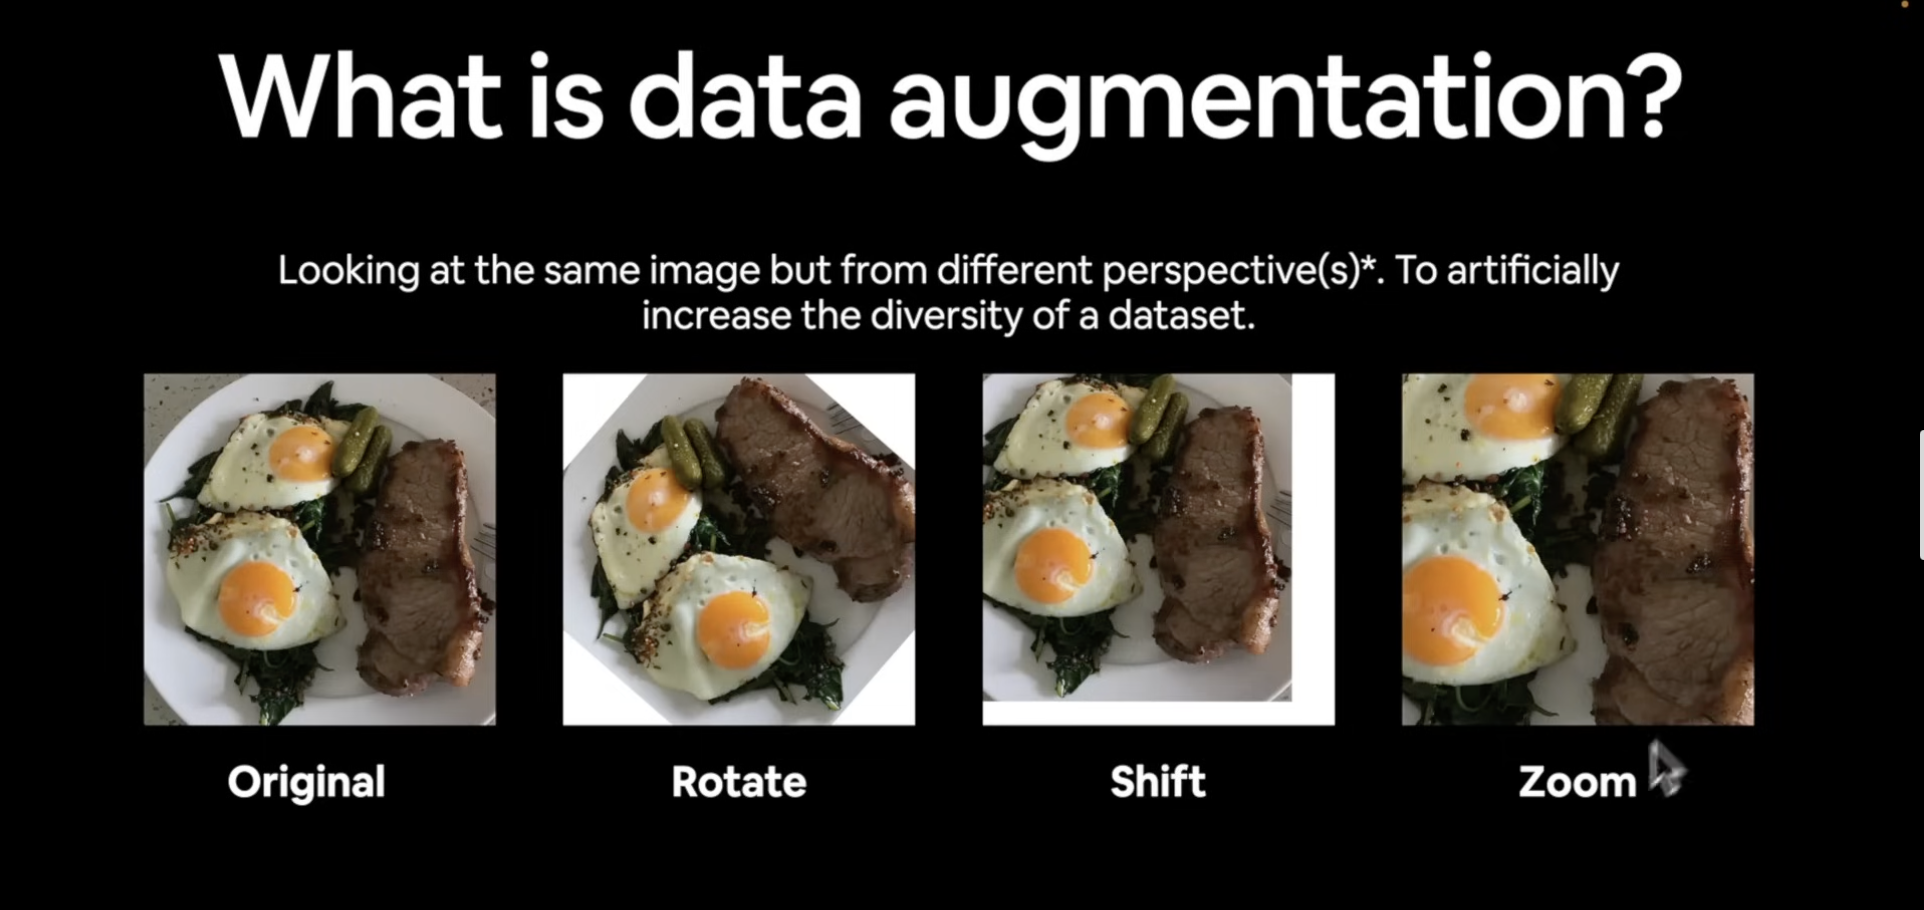

In [ ]:
# Let's look at Trivial Augment -> https://docs.pytorch.org/vision/0.21/auto_examples/transforms/plot_transforms_illustrations.html#trivialaugmentwide:~:text=TrivialAugmentWide

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # -> how intense you want the augmentation to happen. It ranges from 0 to 31
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [ ]:
img_path

In [ ]:
# Get all the image paths
image_path_list = list(img_path.glob("*/*/*.jpg"))
image_path_list[:10]

In [ ]:
# Plot random transformed images

plot_transformed_images(image_paths = image_path_list,
                        transform = train_transform,
                        n = 3,
                        seed = None)



 ## 7. Model 0: TinyVGG without augmentation

Let's replicate TinyVGG architecture from the CNN Explainer: https://poloclub.github.io/cnn-explainer/


### 7.1 Creating transforms and loading data for Model 0

In [ ]:
# Create simple transform
from torchvision import transforms

simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [ ]:
# Loading data - converting to train data and then into dataloader

# 1. Load and transform data
from torchvision import datasets
from torch.utils.data import DataLoader
import os

train_data_simple = datasets.ImageFolder(root = train_dir,
                         transform = simple_transform,
                         target_transform = None)

test_data_simple = datasets.ImageFolder(root = test_dir,
                        transform = simple_transform)

# 2. Turn the datasets into DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset = train_data_simple,
                              batch_size = 32,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset = test_data_simple,
                             batch_size = 32,
                             shuffle = False,
                             num_workers = NUM_WORKERS)

In [ ]:
### 7.2 Create TinyVGG model

In [ ]:
# Creating a TinyVGG model
import torch
from torch import nn

class TinyVGG(nn.Module):
  """Model architecture copying TTinyVGG from CNN Explainer"""

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    super().__init__()

    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = (3, 3),
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = (3, 3),
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2) # default stride value is same as kernel_size
     )

    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = (3, 3),
                  stride = 1,
                  padding = 0),
        nn.ReLU(),

        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = (3, 3),
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = (2, 2))
     )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*13*13,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_layer_1(x)
    # print(x.shape)
    x = self.conv_layer_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # no. of color channel in image data - 3 for RGB
                  hidden_units=10,
                  output_shape=len((class_names))).to(device)

model_0

In [ ]:
len((class_names))

### 7.3 Try a forward pass on a single image (to test the model)

In [ ]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

In [ ]:
# Pass some dummy data through our model_0's forward pass and also check input and output shape of each layer
model_0(image_batch.to(device))

In [ ]:
10*16*16

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [ ]:
# Install torchinfo
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [ ]:
from torchinfo import summary

model = model_0
batch_size = 32
summary(model_0, input_size=[1, 3, 64, 64])

### 7.5 Create train and test loops functions

* `train_step()` - takes in a model and dataloader and trains the model on the dataloader.
* `test_Step()` - takes in a model and dataloader and evaluates the model on the dataloader.

In [ ]:
# Create train_Step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):

  # Put the model in training mode
  model.train()

  # Set up train loss and accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X,y) in enumerate(dataloader):

    # Send the data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X) # we'll get logits as output

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. loss backward
    loss.backward()

    # 5. optimzer step
    optimizer.step()

    # Calculate the accuracy metric. We are converting the y_pred logits on the go. So logits to pred prob
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += ((y_pred_class == y).sum().item() / len(y_pred)) # -> total number of right preds divide by total samples

  # Adjust metrics to get the average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc


In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):

  # Put model in eval mode
  model.eval()

  # Setup test loss and test acc vals
  test_loss, test_acc = 0, 0

  # Turn on inference mode
  with torch.inference_mode():

    for batch, (X,y) in enumerate(dataloader):
    # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate the acc
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  return test_loss, test_acc

### 7.6 Creating a `train()` function to combine `train_step()` and `test_Step()`

In [ ]:
# from tqdm.auto import tqdm

# 1. Create a traqin fn that takes various model parameters +optimizer + dataloader +loss fn

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):

  # 2. Create empty result dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # 3. Loop through epochs
  for epoch in range(epochs):

    train_loss, train_acc = train_step(model = model,
                                       dataloader = train_dataloader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)

    test_loss, test_acc = test_step(model = model,
                                    dataloader = test_dataloader,
                                    loss_fn = loss_fn,
                                    device = device)

    # 4. Print what's happening
    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} |  Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

    # 5. Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. Return the filled results at the end of epochs
  return results

### 7.7 Train and evaluate `model_0`

In [ ]:
# Set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape = 3, # number of cc
                hidden_units = 10,
                output_shape = len(train_data.classes)).to(device)

# Set loss fn and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params = model_0.parameters(),
                             lr = 0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model = model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

### 7.8 Plot the loss curve of model_0

A **loss curve** is a way of tracking your model's progress over time

In [ ]:
model_0_results

In [ ]:
# Get the model_0 results keys
model_0_results.keys()

In [ ]:
model_0_results.values()

In [ ]:
def plot_loss_curve(results: Dict[str, list[float]]): # -> for ex, {'train_loss': [1.1061925143003464]} -> compare the format with the above results parameter in the function
  """Plots training curves of a results dictionary"""
  # Get the loss values of the result dict (training and test)

  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the result dict (training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  # Figure out how many epochs were there
  epochs = range(len(results["train_loss"]))

  # Set up a plot
  plt.figure(figsize=(15, 7))

  # Plot loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = "train_accuracy")
  plt.plot(epochs, test_accuracy, label = "test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()



In [ ]:
plot_loss_curve(model_0_results)

## 8. What should an ideal loss curve look like?

https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves

A loss curve is one of the most helpful ways to troubleshoot a model

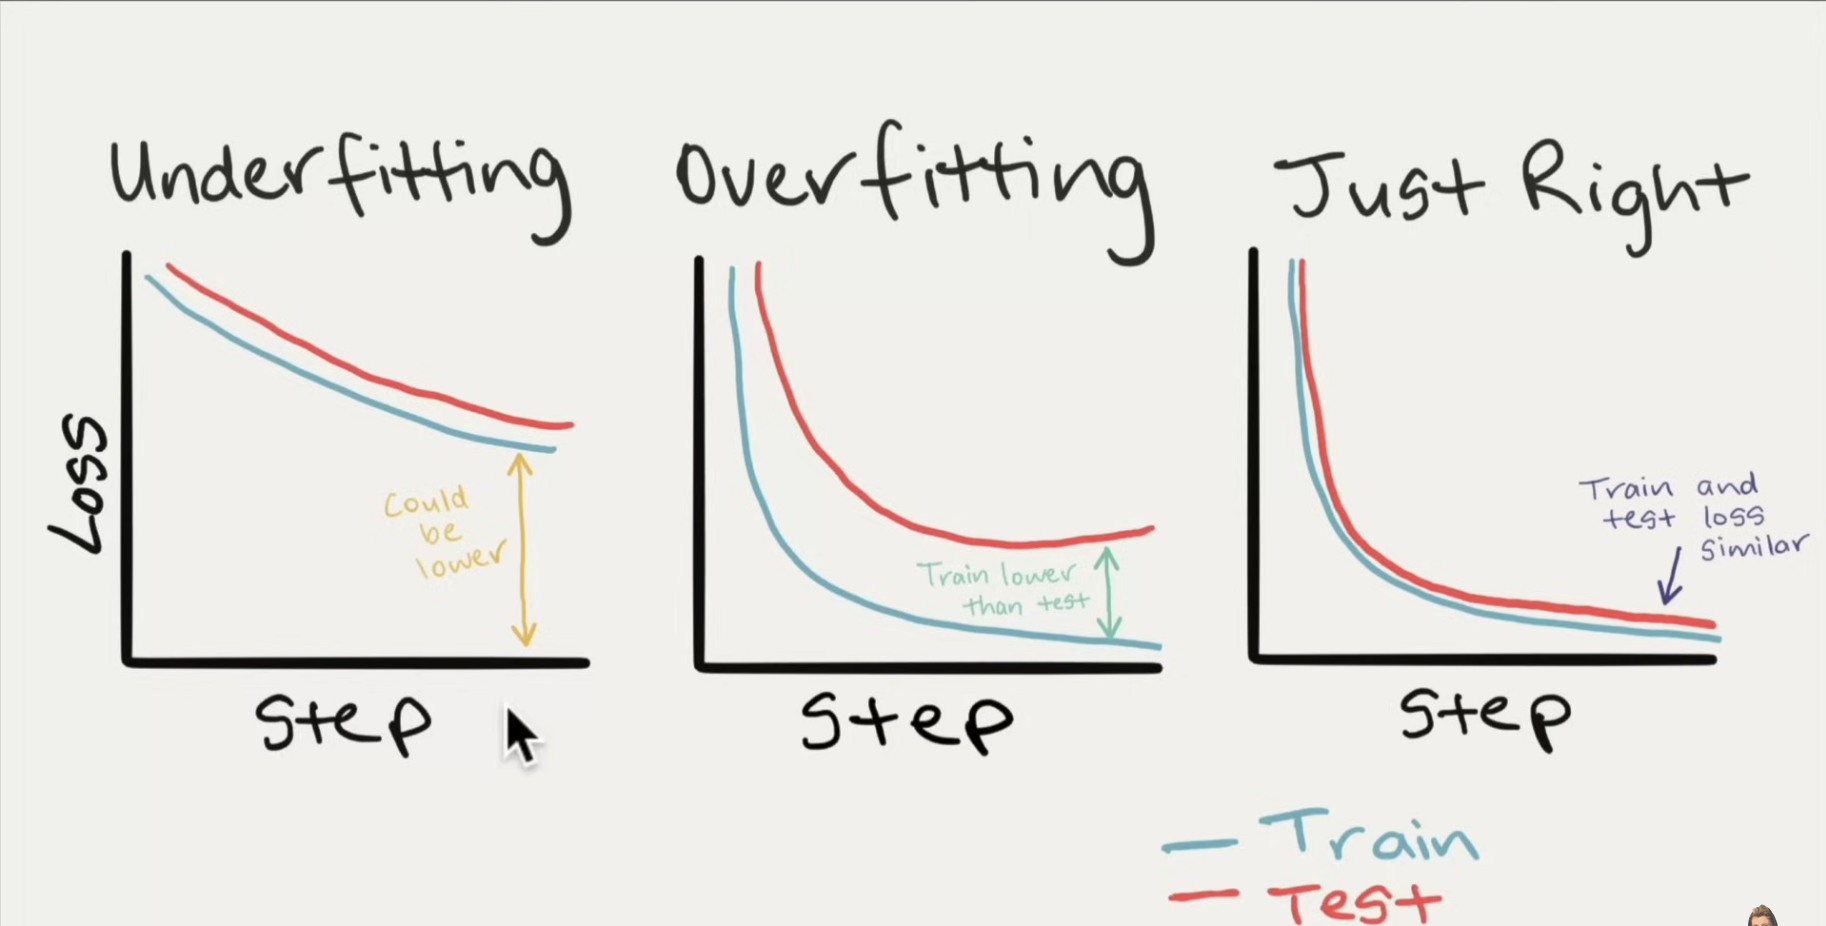

---
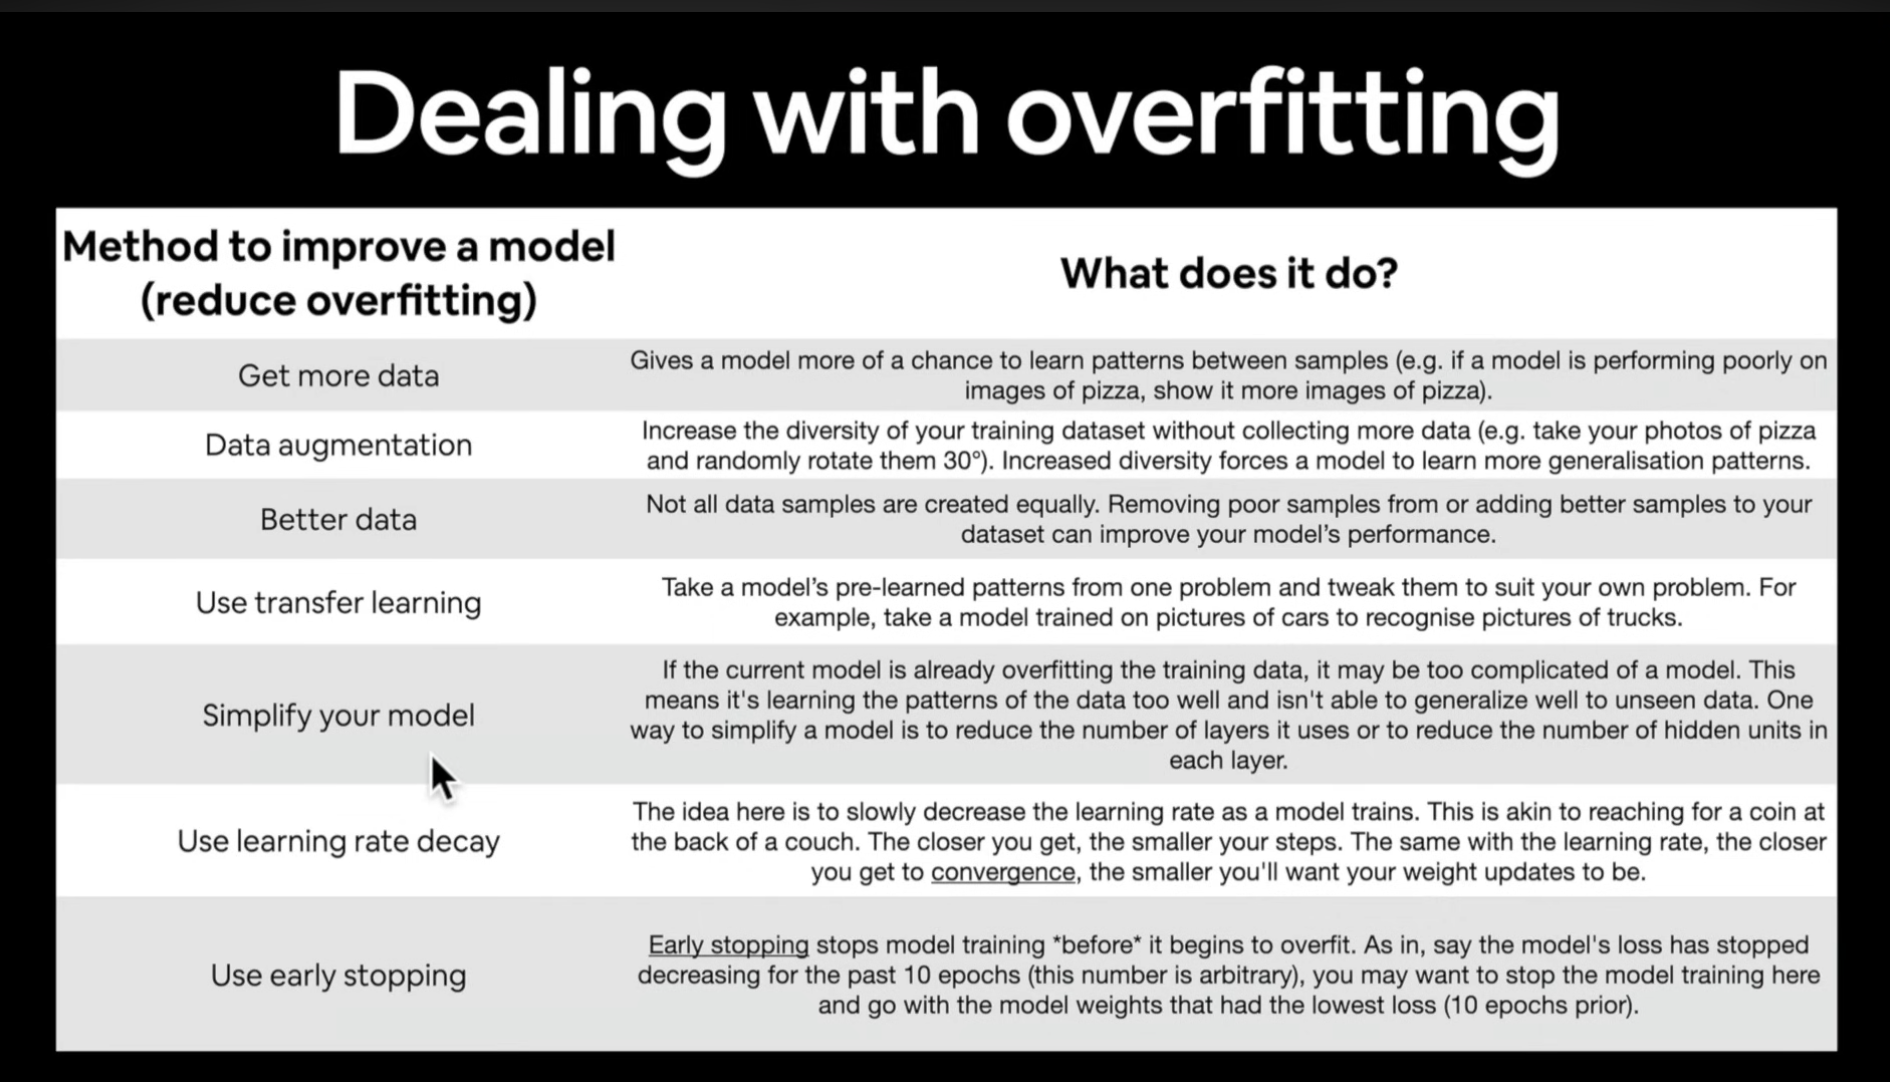

---
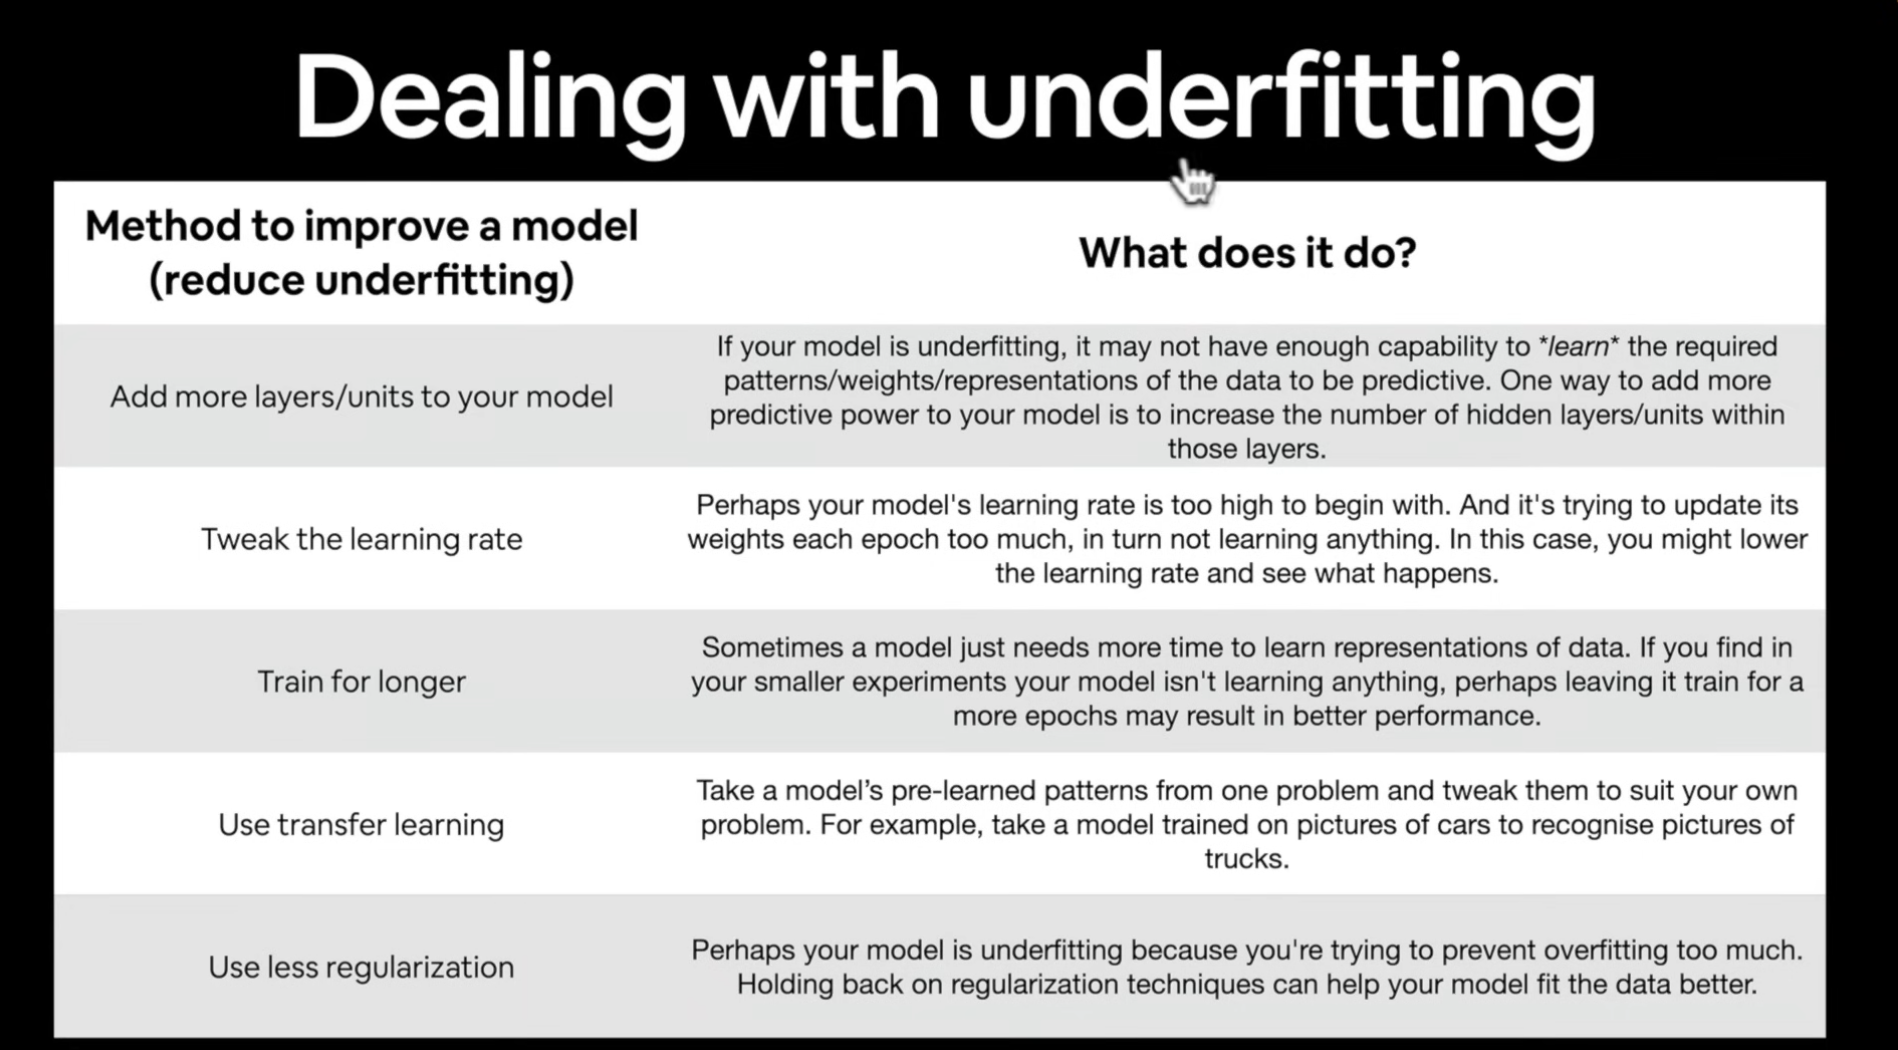

## 9. Model 1: TinyVGG with Data Augmentation

Now let's try another modelling experiment this time using the same model as before but with some data augmentation.

### 9.1 Create transform with data augmentation

In [ ]:
# Create training transform with TrivialAugment
from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

### 9.2 Create train and test `Datasets` and `Dataloader` with data augmentation

In [ ]:
# Turn image folders into datasets
from torchvision import datasets

train_data_augmented = datasets.ImageFolder(root = train_dir,
                                            transform = train_transform_trivial)

test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = test_transform_simple)

In [ ]:
train_dir

In [ ]:
# Turn our datasets into DataLoader
from torch.utils.data import DataLoader

import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_augmented = DataLoader(dataset = train_data_augmented,
                                        batch_size = BATCH_SIZE,
                                        shuffle = True,
                                        num_workers = NUM_WORKERS)

test_dataloader_augmented = DataLoader(dataset = test_data_simple,
                                       batch_size = BATCH_SIZE,
                                       shuffle = False,
                                       num_workers = NUM_WORKERS)

### 9.3 Construct and train `model_1`

This time we will be using same model architecture except this time we've augmented the training data.

In [ ]:
# Create model_1 and send it to target device
torch.manual_seed(42)

model_1 = TinyVGG(input_shape=3,
                hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

Now we have got model and dataloader. Let's create a loss function and an optimizer and call upon our `train()` function to train and evaluate or model

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Number of epochs
NUM_EPOCHS = 5

# Set up loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),
                             lr = 0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

model_1_results = train(model = model_1,
                        train_dataloader = train_dataloader_augmented,
                        test_dataloader = test_dataloader_augmented,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training timr for model_1: {end_time - start_time:.3f} seconds")

In [ ]:
model_1_results

### 9.4 Pot the loss curve of model 1.


In [ ]:
plot_loss_curve(model_1_results)

## 10. Compare our model results

After evaluating our modelling experiments on their own, it's importnat to compare them to each other

There's a few diff ways to do this:
1. Hard coding (what we are doing)
2. PyTorch + tensorboard - https://docs.pytorch.org/docs/2.10/tensorboard.html
3. Weights & Biases - https://wandb.ai/site/experiment-tracking/
4. MLFlow - https://mlflow.org/

In [ ]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

model_0_df

In [ ]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df)) # -> 5

# plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test loss")
plt.xlabel("Epochs")
plt.legend()

# plot train acc
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train acc")
plt.xlabel("Epochs")
plt.legend()

# Plot test acc
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test acc")
plt.xlabel("Epochs")
plt.legend()

## 11. Making a prediction on a custom image

Although we trained model on custom data, how do you make prediction on a sample that's mot either a training or testing dataset.

In [ ]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path/"04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # Get raw link from github
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/images/04-pizza-dad.jpeg")
    print(f'Downloading {custom_image_path}...')
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists")

### 11.1 Loading in a custom image with pytorch

We have to make sure our custom image is in the same format as the data our model was trained on

* In tensor from with datatype(torch.float32)
* of shape 64x64x3
* on the right device

We can read an image into pytorch using -


In [ ]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print(f'Custom image tensor: {custom_image_uint8}')
print(f'Custom image shape: {custom_image_uint8.shape}')
print(f'Custom image datatype: {custom_image_uint8.dtype}')

In [ ]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))

### 11.2 Making a prediction on a custom image with a trained model

In [ ]:
# Try to make a prediciton on an image in uint8 format
model_1.eval()
with torch.inference_mode():
  model_1(custom_image_uint8.to(device))

In [ ]:
# Load in the custom image and convert to torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)
custom_image

In [ ]:
model_1.eval()
with torch.inference_mode():
  model_1(custom_image.to(device))

In [ ]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255
custom_image

In [ ]:
# Create transform pipeline to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
])

custom_image_transformed = custom_image_transform(custom_image)

print(f'original shape: {custom_image.shape}')
print(f'transformed shape: {custom_image_transformed.shape}')

In [ ]:
plt.imshow(custom_image.permute(1, 2, 0))

In [ ]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [ ]:
plt.imshow(custom_image.permute(1, 2, 0))

In [ ]:
# this will error - no batch size. if device related error occur, add .to(device) when forward passing to model_1
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed)

In [ ]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(dim=0).shape

In [ ]:
# Thise should work (add a batch size)
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

custom_image_pred

To make a prediciton on a custom image we had to:
- load the image and turn it into a tensor
- make sure we had to make sure the image was the same datatype as the model
- make sure the image was the same shape as the data model was trained on (3, 64, 64)
- make sure the image was on the same device as our model

In [ ]:
# Convert logits -> prediction probs
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

In [ ]:
# pred probs to pred labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

### 11.3 Putting custom image prdiciton together: building a function

ideal outcome:

A function where we pass an image path to and have our model predict on that image and plot the image + prediction

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = device):

  """Makes a prediciton on a target image with a trained model and plots the image and prediciton"""

  # load the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Devide the image pixel values by 255 to get them between 0, 1 as range
  target_image = target_image / 255.

  # Transform if necessary
  if transform:
    target_image = transform(target_image)

  # Make sure the model is on target device
  model.to(device)

  # Turn on eval and make prediction
  model.eval()
  with torch.inference_mode():
    target_image = target_image.unsqueeze(dim=0)

    # make a pred on the image with extra dimension
    target_image_pred = model(target_image.to(device)) # make sure target is on the right device

  # convert logits -> pred prob
  target_image_pred_prob = torch.softmax(target_image_pred, dim=1)

  #pred prob -> pred labels
  target_image_pred_label = torch.argmax(target_image_pred_prob, dim=1)

  # plot the image alongide the predicitona dn pred prob
  plt.imshow(target_image.squeeze().permute(1, 2, 0)) # remove batch dim and rearrange h,w,c

  if class_names:
    title = f"pred: {class_names[target_image_pred_label.cpu()]} | prob: {target_image_pred_prob.max().cpu():.3f}"
  else:
    title = f"pred: {target_image_pred_label} | prob: {target_image_pred_prob.max().cpu():.3f}"

  plt.title(title)
  plt.axis(False)

In [ ]:
pred_and_plot_image(model = model_1,
                    image_path = custom_image_path,
                    class_names = class_names,
                    transform = custom_image_transform,
                    device =device)

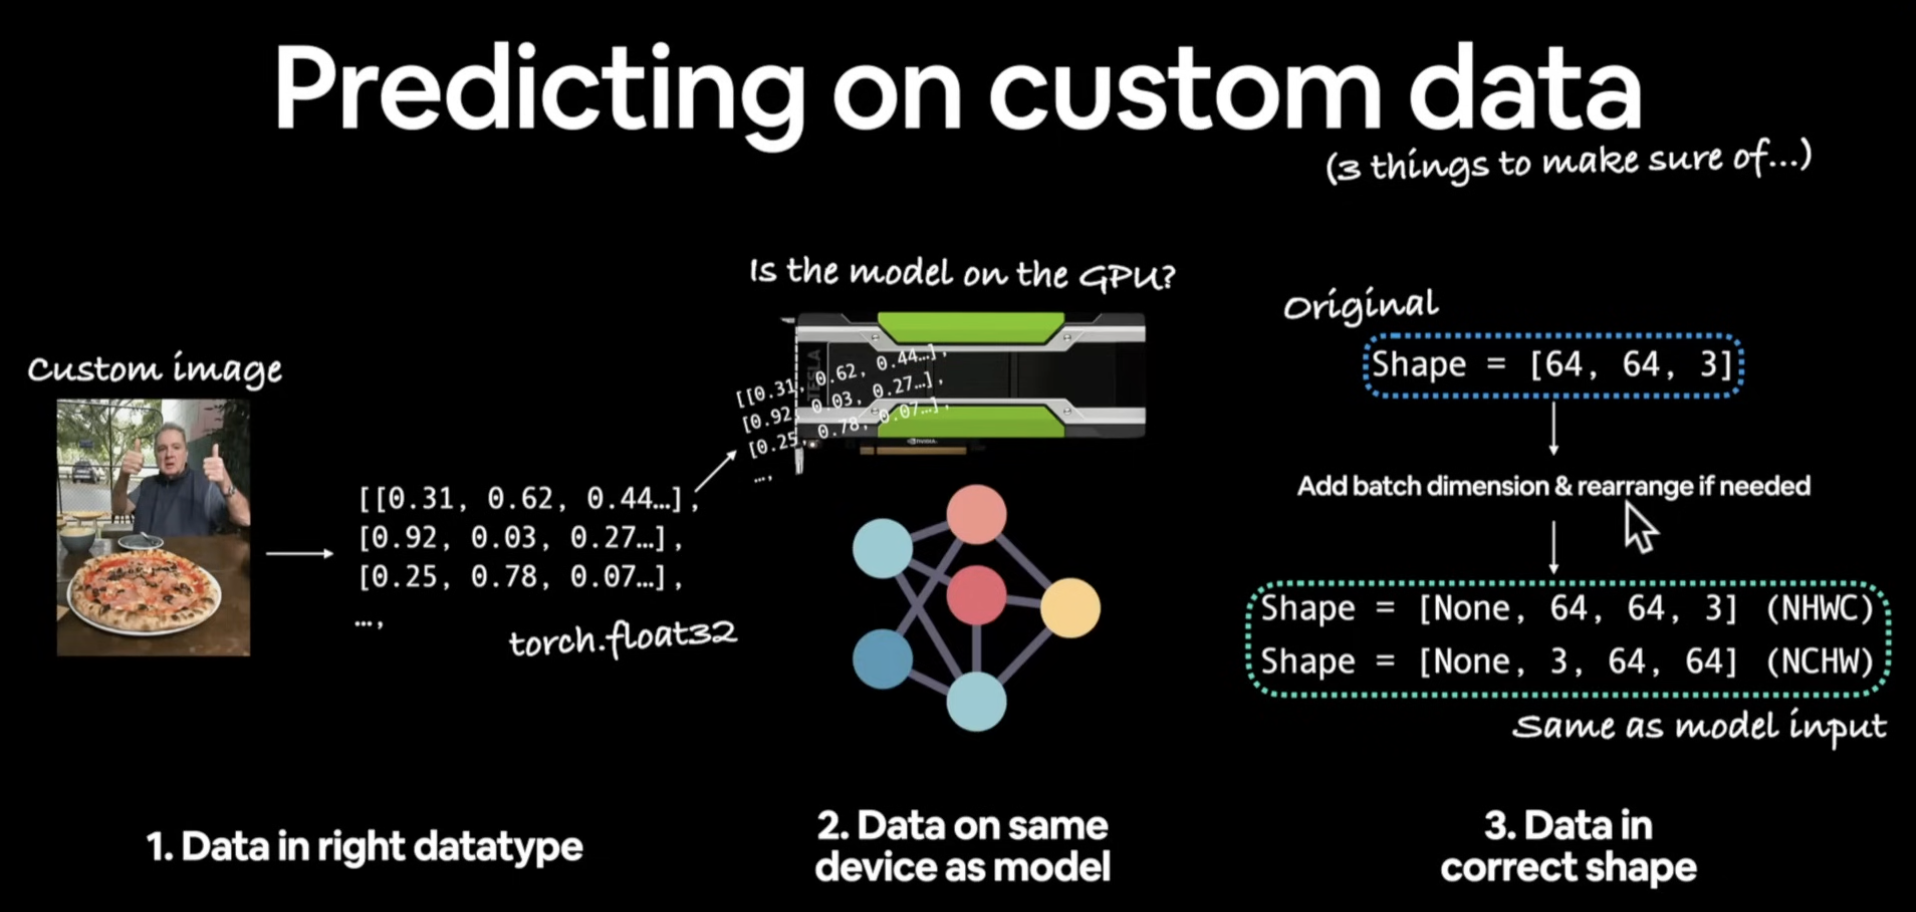

---
## **Exercises**

---
Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

> Although there are more methods but these are the top 3 in my opinion or may be go-to improvements that can be made:
> 1. Adding more **hidden units** would help as it give the capability to learn more about the data.
> 2. Instead of big learning steps, we can tweak the **learning rate** to more smaller number to allow the model to learn more and that would eventually help in overcoming the underfitting of the model.
> 3. Giving **More Training Time** meaning adding more epochs gives our model more training time to learn the patterns. This is also an important factor to overcome the underfitting.

### 1.Recreate the data loading functions we built in sections 1, 2, 3 and 4. You should have train and test DataLoader's ready to use.

In [ ]:
import requests
from pathlib import Path
import zipfile

# let's setup "data" folder
ex_data_path = Path('ex_data/')
ex_image_path = Path(ex_data_path /'pizza_steak_sushi') # at this point, the folder is empty

print(f'data path (main dir): {ex_data_path} \n')
print(f'image path (child dir): {ex_image_path}\n\n')
'''
At this point, this doesn't create any folders. The Path() is just creating a reference.
Path() is just reading the recipe — you know what you need and where things go, but nothing's actually happened in the kitchen yet.
.mkdir() is when you actually start cooking.
'''

data path (main dir): ex_data 

image path (child dir): ex_data/pizza_steak_sushi




"\nAt this point, this doesn't create any folders. The Path() is just creating a reference.\nPath() is just reading the recipe — you know what you need and where things go, but nothing's actually happened in the kitchen yet.\n.mkdir() is when you actually start cooking.\n"

In [ ]:
# check if the image folder already exist. if not, make one
if ex_image_path.is_dir():
  print(f'{ex_image_path} already exist. Skipping downloading..\n\n')
else:
  print(f'Downloading {ex_image_path} under the {ex_data_path}..')
  ex_image_path.mkdir(parents=True, exist_ok = True)
  print(f'Downloading completed..\n\n')

'''
This is where the folder gets created. That's why we have also added the if condition to check if this has been executed before.
'''

"\nThis is where the folder gets created. That's why we have also added the if condition to check if this has been executed before.\n"

In [ ]:
# Download the dataset
with open(ex_data_path/'pizza_steak_sushi.zip', 'wb') as f:
  request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
  print(f'Downloading..')
  f.write(request.content)
  print(f'Downloading completed \n\n')

'''
Here we download the dataset into the ex_data_path folder.
The data (images of pizza steak sushi) are in binary form something like PK♣♦ ☺ ♥▬←→ (weird chars)
With f.write():
Takes whatever is in request.content (the raw bytes)
Physically writes it into pizza_steak_sushi.zip on disk
Now it persists — you can see it in the Colab Files panel

Analogy
requests.get() is like receiving a package at your door — it arrives but you're just holding it.
f.write() is putting it on the shelf — now it's actually stored somewhere.
'''

Downloading..




"\nHere we download the dataset into the ex_data_path folder.\nThe data (images of pizza steak sushi) are in binary form something like PK♣♦ ☺ ♥▬←→ (weird chars)\nWith f.write():\nTakes whatever is in request.content (the raw bytes)\nPhysically writes it into pizza_steak_sushi.zip on disk\nNow it persists — you can see it in the Colab Files panel\n\nAnalogy\nrequests.get() is like receiving a package at your door — it arrives but you're just holding it.\nf.write() is putting it on the shelf — now it's actually stored somewhere.\n"

In [ ]:
# Unzip the downloaded zip file into ex_image_path
with zipfile.ZipFile(ex_data_path/'pizza_steak_sushi.zip', 'r') as f:
  print(f'Unzipping..')
  f.extractall(ex_image_path)
  print(f'unzipping completed..\n\n')

'''
Here, we are using the r mode or read mode where it pulls from disk into RAM and then unzipping/extracting it.
'''

Unzipping..
unzipping completed..




'\nHere, we are using the r mode or read mode where it pulls from disk into RAM and then unzipping/extracting it.\n'

In [ ]:
# Setup train and test paths
ex_train_dir = ex_image_path/'train'
ex_test_dir = ex_image_path/'test'

ex_train_dir, ex_test_dir

(PosixPath('ex_data/pizza_steak_sushi/train'),
 PosixPath('ex_data/pizza_steak_sushi/test'))

In [ ]:
# we are doing this just to see couple of images
import random
from PIL import Image

random.seed(42)

ex_image_path_list = list(ex_image_path.glob('*/*/*.jpg'))
print(ex_image_path_list[:2])

'''
ex_data/pizza_steak_sushi  /  *  /  *  /  *.jpg
        (ex_image_path)      ↑     ↑      ↑
                           train  pizza  any .jpg file
                           test   steak
                                  sushi
'''

[PosixPath('ex_data/pizza_steak_sushi/test/sushi/2540511.jpg'), PosixPath('ex_data/pizza_steak_sushi/test/sushi/3196729.jpg')]


'\nex_data/pizza_steak_sushi  /  *  /  *  /  *.jpg\n        (ex_image_path)      ↑     ↑      ↑\n                           train  pizza  any .jpg file\n                           test   steak\n                                  sushi\n'

In [ ]:
print(ex_image_path)

ex_data/pizza_steak_sushi


In [ ]:
# now we'll pick any random image from the ex_image_path_list
ex_random_image = random.choice(ex_image_path_list)
print(ex_random_image)

ex_data/pizza_steak_sushi/test/pizza/309892.jpg


In [ ]:
# now we'll assign the name to the image and it is done on the basis pr the label or class
ex_image_class = ex_random_image.parent.stem
print(f'The image is: {ex_image_class}')

The image is: pizza


image is: pizza
image height: 333
image width: 512


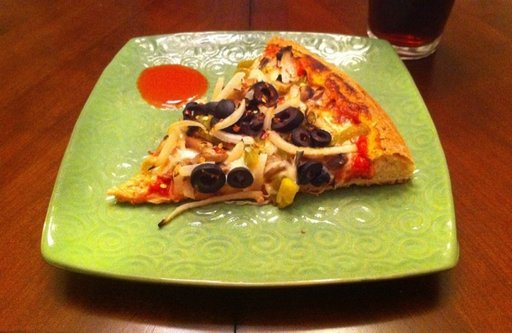

In [ ]:
# let's visualize the image
ex_image = Image.open(ex_random_image)
print(f'image is: {ex_image_class}')
print(f'image height: {ex_image.height}')
print(f'image width: {ex_image.width}')
ex_image

In [ ]:
# The image we are seeing are not pytorch friendly i.e. not in tensor yet. Let's prepare to transform these images

from torchvision import transforms

ex_data_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

'''
Here we are transforming the image by resizing it to 64x64 as it is the ideal hxw for rgb images. We are also rotating the images to make the model learning more better so the model can determine even if the image's orientation is bit different.
Lastly we are converting into tensor so the image can be trained and tested.
'''

"\nHere we are transforming the image by resizing it to 64x64 as it is the ideal hxw for rgb images. We are also rotating the images to make the model learning more better so the model can determine even if the image's orientation is bit different.\nLastly we are converting into tensor so the image can be trained and tested.\n"

In [ ]:
# Now let's convert into datasets
from torchvision.datasets import ImageFolder

ex_train_dataset = ImageFolder(root = ex_train_dir,
                            transform = ex_data_transform,
                            target_transform = None)

ex_test_dataset = ImageFolder(root = ex_test_dir,
                              transform = ex_data_transform)

ex_train_dataset, ex_test_dataset

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: ex_data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: ex_data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
# Now let's convert these datasets into DataLoader so the dataset can be interated over for training and test purposes
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

ex_train_dataloader = DataLoader(dataset = ex_train_dataset,
                                 batch_size = BATCH_SIZE,
                                 shuffle = True,
                                 num_workers = NUM_WORKERS)

ex_test_dataloader = DataLoader(dataset = ex_test_dataset,
                                batch_size = BATCH_SIZE,
                                num_workers = NUM_WORKERS)

ex_train_dataloader, ex_test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bb64170a5a0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bb641719640>)

###2.Recreate model_0 we built in section 7.

In [ ]:
ex_train_dataset.classes

['pizza', 'steak', 'sushi']

In [ ]:
ex_train_dataset.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
from torch import nn

class TinyVGGV1(nn.Module):

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    super().__init__()

    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),

        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),

        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*13*13,
                  out_features = output_shape)
    )

  def forward(self, x):
    x = self.conv_layer_1(x)
    #print(f'Shape after conv_layer_1: {x.shape}')
    x = self.conv_layer_2(x)
    #print(f'Shape after conv_layer_2: {x.shape}')
    x = self.classifier(x)
    #print(f'Shape after classifier: {x.shape}')
    return x

In [ ]:
model_0_v1 = TinyVGGV1(input_shape=3,
                       hidden_units = 32,
                       output_shape = len(ex_train_dataset.classes)).to(device)

model_0_v1

TinyVGGV1(
  (conv_layer_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5408, out_features=3, bias=True)
  )
)

In [ ]:
# trying our model on a single sample

train_batch, train_batch_label = next(iter(ex_train_dataloader))
train_batch.shape, train_batch_label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
train_batch.ndim, train_batch_label.ndim

(4, 1)

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo


In [ ]:
next(model_0_v1.parameters()).device

device(type='cuda', index=0)

In [ ]:
import torchinfo
from torchinfo import summary

model = model_0_v1
batch_size = 32

summary(model, input_size=[batch_size, 3, 64, 64])



Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGV1                                [32, 3]                   --
├─Sequential: 1-1                        [32, 32, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 32, 62, 62]          896
│    └─ReLU: 2-2                         [32, 32, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 32, 60, 60]          9,248
│    └─ReLU: 2-4                         [32, 32, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 32, 30, 30]          --
├─Sequential: 1-2                        [32, 32, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 32, 28, 28]          9,248
│    └─ReLU: 2-7                         [32, 32, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 32, 26, 26]          9,248
│    └─ReLU: 2-9                         [32, 32, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 32, 13, 13]          --
├─Seq

###3.Create training and testing functions for model_0.

In [ ]:
len(ex_train_dataloader)

8

In [ ]:
len(ex_train_dataset)

225

In [ ]:
225/32

7.03125

In [ ]:
len(ex_test_dataset)

75

In [ ]:
75/32

2.34375

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0_v1.parameters(),
                            lr = 0.001)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 5

for epoch in range(epochs):

  ex_train_loss, ex_train_acc = 0, 0
  ex_test_loss, ex_test_acc = 0, 0

  for batch, (X,y) in enumerate(ex_train_dataloader):

    X, y = X.to(device), y.to(device)

    # Training
    model_0_v1.train()

    optimizer.zero_grad()

    ex_y_pred = model_0_v1(X)

    ex_pred_labels = torch.argmax(ex_y_pred, dim=1)

    ex_loss = loss_fn(ex_y_pred, y)
    ex_train_loss += ex_loss.item()

    ex_acc = ((ex_pred_labels == y).sum().item()/len(ex_y_pred))
    ex_train_acc += ex_acc

    ex_loss.backward()

    optimizer.step()

  # testing
  model_0_v1.eval()

  with torch.inference_mode():

    for batch, (X,y) in enumerate(ex_test_dataloader):

      X, y = X.to(device), y.to(device)

      ex_y_logits = model_0_v1(X)

      ex_pred_labels_test = torch.argmax(ex_y_logits, dim=1)
      ex_loss_test = loss_fn(ex_y_logits, y)

      ex_acc_test = ((ex_pred_labels_test == y).sum().item()/len(ex_y_logits))

      ex_test_loss += ex_loss_test.item()
      ex_test_acc += ex_acc_test

  ex_train_loss /= len(ex_train_dataloader)
  ex_train_acc /= len(ex_train_dataloader)
  ex_test_loss /= len(ex_test_dataloader)
  ex_test_acc /= len(ex_test_dataloader)

  print(f'Epoch: {epoch+1} | train_loss: {ex_train_loss:.4f} | train_acc: {ex_train_acc:.4f} | test_loss: {ex_test_loss:.4f} | test_acc: {ex_test_acc:.4f}')



Epoch: 1 | train_loss: 1.0991 | train_acc: 0.2344 | test_loss: 1.1098 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0920 | train_acc: 0.4258 | test_loss: 1.1192 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0885 | train_acc: 0.4258 | test_loss: 1.1274 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1076 | train_acc: 0.3047 | test_loss: 1.1333 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0894 | train_acc: 0.4258 | test_loss: 1.1372 | test_acc: 0.2604


In [ ]:
len(ex_train_dataset)

225

In [ ]:
ex_data_transform_v1 = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()

])

In [ ]:
from torchvision.datasets import ImageFolder

train_data_simple_v1 = ImageFolder(root = ex_train_dir,
                         transform = ex_data_transform_v1,
                         target_transform = None)

test_data_simple_v1 = ImageFolder(root = ex_test_dir,
                        transform = ex_data_transform_v1)

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

ex_train_sample_dataloader = DataLoader(dataset = train_data_simple_v1,
                                 batch_size = BATCH_SIZE,
                                 shuffle = True,
                                 num_workers = NUM_WORKERS)

ex_test__sample_dataloader = DataLoader(dataset = test_data_simple_v1,
                                batch_size = BATCH_SIZE,
                                num_workers = NUM_WORKERS)

ex_train_sample_dataloader, ex_test__sample_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bb6417939b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bb641792db0>)

In [ ]:
# let's try to functionize the above
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               device = device):

  ex_train_loss_v2, ex_train_acc_v2 = 0, 0

  for batch, (X,y) in enumerate(dataloader):

    X, y = X.to(device), y.to(device)

    # put the model in training mode
    model.train()

    # optimize zero grad
    optimizer.zero_grad()

    # forward pass
    ex_y_pred_v2 = model(X)

    # convert logits to labels
    ex_pred_labels_v2 = torch.argmax(ex_y_pred_v2, dim=1)

    # keep the loss as raw values tensor
    ex_loss_v2 = loss_fn(ex_y_pred_v2, y)

    # accumulate the float values
    ex_train_loss_v2 += ex_loss_v2.item()

    ex_acc_v2 = ((ex_pred_labels_v2 == y).sum().item()/len(ex_y_pred_v2))
    ex_train_acc_v2 += ex_acc_v2

  ex_train_loss_v2 /= len(dataloader)
  ex_train_acc_v2 /= len(dataloader)

  return ex_train_loss_v2, ex_train_acc_v2

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn = loss_fn,
              device = device):

  model.eval()

  with torch.inference_mode():

    ex_test_loss_v2, ex_test_acc_v2 = 0, 0

    for batch, (X,y) in enumerate(dataloader):

      X, y = X.to(device), y.to(device)

      ex_y_logits_v2 = model(X)

      ex_y_pred_labels_test_v2 = torch.argmax(ex_y_logits_v2, dim=1)

      ex_loss_test_v2 = loss_fn(ex_y_logits_v2, y).item()
      ex_acc_test_v2 = ((ex_y_pred_labels_test_v2 == y).sum().item()/len(ex_y_logits_v2))

      ex_test_loss_v2 += ex_loss_test_v2
      ex_test_acc_v2 += ex_acc_test_v2

  ex_test_loss_v2 /= len(dataloader)
  ex_test_acc_v2 /= len(dataloader)

  return ex_test_loss_v2, ex_test_acc_v2


In [ ]:
def train(model: torch.nn.Module,
          train_data_loader: torch.utils.data.DataLoader,
          test_data_loader: torch.utils.data.DataLoader,
          loss_fn = loss_fn,
          optimizer = optimizer,
          device = device):

  num_of_epochs = 20

  ex_results_v2 = {"train_loss": [],
                   "train_acc": [],
                   "test_loss": [],
                   "test_acc": []}

  for epoch in range(num_of_epochs):

    ex_train_loss_v3, ex_train_acc_v3 = train_step(
        model = model,
        dataloader = train_data_loader,
        loss_fn = loss_fn,
        optimizer = optimizer,
        device = device
    )

    ex_test_loss_v3, ex_test_acc_v3 = test_step(
        model = model,
        dataloader = test_data_loader,
        device = device
    )

    ex_results_v2["train_loss"].append(ex_train_loss_v3)
    ex_results_v2["train_acc"].append(ex_train_acc_v3)
    ex_results_v2["test_loss"].append(ex_test_loss_v3)
    ex_results_v2["test_acc"].append(ex_test_acc_v3)

    print(f'Epoch: {epoch+1} | train_loss: {ex_train_loss_v3:.4f} | train_acc: {ex_train_acc_v3:.4f} | test_loss: {ex_test_loss_v3:.4f} | test_acc: {ex_test_acc_v3:.4f}')

  return ex_results_v2



In [ ]:
model_results = train(
    model = model_0_v1,
    train_data_loader = ex_train_sample_dataloader,
    test_data_loader = ex_test__sample_dataloader,
    loss_fn = loss_fn,
    optimizer = optimizer,
    device = device
)

model_results

Epoch: 1 | train_loss: 1.1014 | train_acc: 0.2812 | test_loss: 1.0901 | test_acc: 0.5417
Epoch: 2 | train_loss: 1.1001 | train_acc: 0.2812 | test_loss: 1.0902 | test_acc: 0.5417
Epoch: 3 | train_loss: 1.1004 | train_acc: 0.2812 | test_loss: 1.0900 | test_acc: 0.5417
Epoch: 4 | train_loss: 1.0962 | train_acc: 0.4023 | test_loss: 1.0892 | test_acc: 0.5417
Epoch: 5 | train_loss: 1.0997 | train_acc: 0.2812 | test_loss: 1.0902 | test_acc: 0.5417


{'train_loss': [1.101445123553276,
  1.1001024097204208,
  1.1004321426153183,
  1.0962408930063248,
  1.0997415482997894],
 'train_acc': [0.28125, 0.28125, 0.28125, 0.40234375, 0.28125],
 'test_loss': [1.0900717973709106,
  1.0901791254679363,
  1.0900336901346843,
  1.0892278750737507,
  1.090174913406372],
 'test_acc': [0.5416666666666666,
  0.5416666666666666,
  0.5416666666666666,
  0.5416666666666666,
  0.5416666666666666]}

In [ ]:
model_0_v2 = TinyVGGV1(
    input_shape=3,
    hidden_units=32,
    output_shape=len(ex_train_dataset.classes)  # keeps it dynamic
).to(device)

model_0_v2

TinyVGGV1(
  (conv_layer_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5408, out_features=3, bias=True)
  )
)

In [ ]:
optimizer_v2 = torch.optim.Adam(params=model_0_v2.parameters(), lr=0.001)

In [ ]:
model_results_v2 = train(
    model=model_0_v2,
    train_data_loader=ex_train_sample_dataloader,
    test_data_loader=ex_test__sample_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_v2,
    device=device
)

model_results_v2

Epoch: 1 | train_loss: 1.0993 | train_acc: 0.2773 | test_loss: 1.0924 | test_acc: 0.5417
Epoch: 2 | train_loss: 1.0964 | train_acc: 0.3984 | test_loss: 1.0913 | test_acc: 0.5417
Epoch: 3 | train_loss: 1.1053 | train_acc: 0.2695 | test_loss: 1.0927 | test_acc: 0.5312
Epoch: 4 | train_loss: 1.0969 | train_acc: 0.4023 | test_loss: 1.0925 | test_acc: 0.5417
Epoch: 5 | train_loss: 1.0974 | train_acc: 0.3984 | test_loss: 1.0923 | test_acc: 0.5417
Epoch: 6 | train_loss: 1.0977 | train_acc: 0.3984 | test_loss: 1.0916 | test_acc: 0.5417
Epoch: 7 | train_loss: 1.1046 | train_acc: 0.2773 | test_loss: 1.0925 | test_acc: 0.5417
Epoch: 8 | train_loss: 1.1038 | train_acc: 0.2812 | test_loss: 1.0919 | test_acc: 0.5417
Epoch: 9 | train_loss: 1.0982 | train_acc: 0.2773 | test_loss: 1.0919 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.0989 | train_acc: 0.2812 | test_loss: 1.0928 | test_acc: 0.5417
Epoch: 11 | train_loss: 1.1037 | train_acc: 0.2812 | test_loss: 1.0924 | test_acc: 0.5312
Epoch: 12 | train_l

{'train_loss': [1.0992679297924042,
  1.0964236706495285,
  1.1053315550088882,
  1.0968641638755798,
  1.0973549783229828,
  1.0976985096931458,
  1.1045665889978409,
  1.103806957602501,
  1.098218634724617,
  1.0988598614931107,
  1.1036730110645294,
  1.1030382812023163,
  1.1060162782669067,
  1.1039187610149384,
  1.1038309782743454,
  1.1043419390916824,
  1.1039136946201324,
  1.0960025042295456,
  1.0997740030288696,
  1.1045835316181183],
 'train_acc': [0.27734375,
  0.3984375,
  0.26953125,
  0.40234375,
  0.3984375,
  0.3984375,
  0.27734375,
  0.28125,
  0.27734375,
  0.28125,
  0.28125,
  0.27734375,
  0.28125,
  0.28515625,
  0.2734375,
  0.28515625,
  0.28125,
  0.40625,
  0.28125,
  0.28515625],
 'test_loss': [1.0924471219380696,
  1.0913169781366985,
  1.0927398999532063,
  1.0924817721048992,
  1.092273434003194,
  1.0915719270706177,
  1.0925142367680867,
  1.091867446899414,
  1.0919222831726074,
  1.0927709738413494,
  1.0924033323923747,
  1.092778245608012,
  1.